# Dry Bean Classification

 Name:Ananya D

 Organisation:Entri Elevate

 Date:

 1. **Overview** **of problem statement**

 Dry beans are cultivated all over the world and have many varieties. Identifying the variety of dry beans from images is difficult manually because they look similar in size and shape. Different geometric features like area, perimeter, aspect ratio are used to distinguish them. If we can classify them automatically using Machine Learning, it will help in agriculture, seed sorting, and quality control.

 2. **Objective**

 To build and compare at least 5 classification models to correctly classify 7 different types of Dry Beans from their geometric features and find the best model with highest accuracy.

 3. **Data** **Description**

 -Source: UCI ML Repository
 -features:1. Area, 2. Perimeter, 3. MajorAxisLength, 4. MinorAxisLength, 5. AspectRation, 6. Eccentricity, 7. ConvexArea, 8. EquivDiameter, 9. Extent, 10. Solidity, 11. roundness, 12. Compactness, 13. ShapeFactor1, 14. ShapeFactor2, 15. ShapeFactor3, 16. ShapeFactor4





**4. Data Collection**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_excel('/content/drive/MyDrive/Data/Dry_Bean_Dataset.xlsx')
df

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13606,42097,759.696,288.721612,185.944705,1.552728,0.765002,42508,231.515799,0.714574,0.990331,0.916603,0.801865,0.006858,0.001749,0.642988,0.998385,DERMASON
13607,42101,757.499,281.576392,190.713136,1.476439,0.735702,42494,231.526798,0.799943,0.990752,0.922015,0.822252,0.006688,0.001886,0.676099,0.998219,DERMASON
13608,42139,759.321,281.539928,191.187979,1.472582,0.734065,42569,231.631261,0.729932,0.989899,0.918424,0.822730,0.006681,0.001888,0.676884,0.996767,DERMASON
13609,42147,763.779,283.382636,190.275731,1.489326,0.741055,42667,231.653248,0.705389,0.987813,0.907906,0.817457,0.006724,0.001852,0.668237,0.995222,DERMASON


 **5. Data preprocessing**

In [ ]:
print(df.head())
print(df.shape)

    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0  28395    610.291       208.178117       173.888747      1.197191   
1  28734    638.018       200.524796       182.734419      1.097356   
2  29380    624.110       212.826130       175.931143      1.209713   
3  30008    645.884       210.557999       182.516516      1.153638   
4  30140    620.134       201.847882       190.279279      1.060798   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
0      0.549812       28715     190.141097  0.763923  0.988856   0.958027   
1      0.411785       29172     191.272750  0.783968  0.984986   0.887034   
2      0.562727       29690     193.410904  0.778113  0.989559   0.947849   
3      0.498616       30724     195.467062  0.782681  0.976696   0.903936   
4      0.333680       30417     195.896503  0.773098  0.990893   0.984877   

   Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  Class  
0     0.913358      0.007332  

In [ ]:
df.isnull().sum()

,0
Area,0
Perimeter,0
MajorAxisLength,0
MinorAxisLength,0
AspectRation,0
Eccentricity,0
ConvexArea,0
EquivDiameter,0
Extent,0
Solidity,0


In [ ]:
Q1=np.percentile(df['Area'],25)
Q3=np.percentile(df['Area'],75)
IQR=Q3-Q1
lower_bound=Q1-(1.5*IQR)
upper_bound=Q3+(1.5*IQR)
print(Q1,Q3)
print(IQR)
print(lower_bound,upper_bound)

36328.0 61332.0
25004.0
-1178.0 98838.0


In [ ]:
print(df.skew(numeric_only=True))

Area               2.952931
Perimeter          1.626124
MajorAxisLength    1.357815
MinorAxisLength    2.238211
AspectRation       0.582573
Eccentricity      -1.062824
ConvexArea         2.941821
EquivDiameter      1.948958
Extent            -0.895348
Solidity          -2.550093
roundness         -0.635749
Compactness        0.037115
ShapeFactor1      -0.534141
ShapeFactor2       0.301226
ShapeFactor3       0.242481
ShapeFactor4      -2.759483
dtype: float64


In [ ]:
x=df.drop('Class', axis=1)
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)
x_scaled


array([[-0.84074853, -1.1433189 , -1.30659814, ...,  2.40217287,
         1.92572347,  0.83837103],
       [-0.82918764, -1.01392388, -1.39591111, ...,  3.10089314,
         2.68970162,  0.77113842],
       [-0.80715717, -1.07882906, -1.25235661, ...,  2.23509147,
         1.84135576,  0.91675514],
       ...,
       [-0.37203825, -0.44783294, -0.45047814, ...,  0.28920441,
         0.33632829,  0.39025114],
       [-0.37176543, -0.42702856, -0.42897404, ...,  0.22837538,
         0.2489734 ,  0.03644001],
       [-0.37135619, -0.38755718, -0.2917356 , ..., -0.12777587,
        -0.2764814 ,  0.71371948]])

**EDA**

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [ ]:
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


1. Countplot

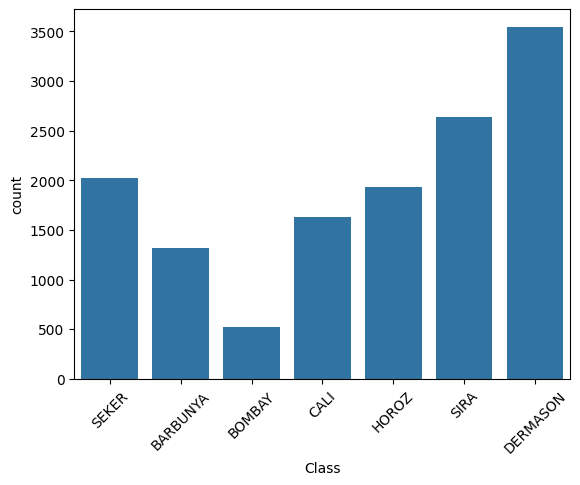

In [ ]:
sns.countplot(x='Class',data=df)
plt.xticks(rotation=45)
plt.show()

2. Histogram

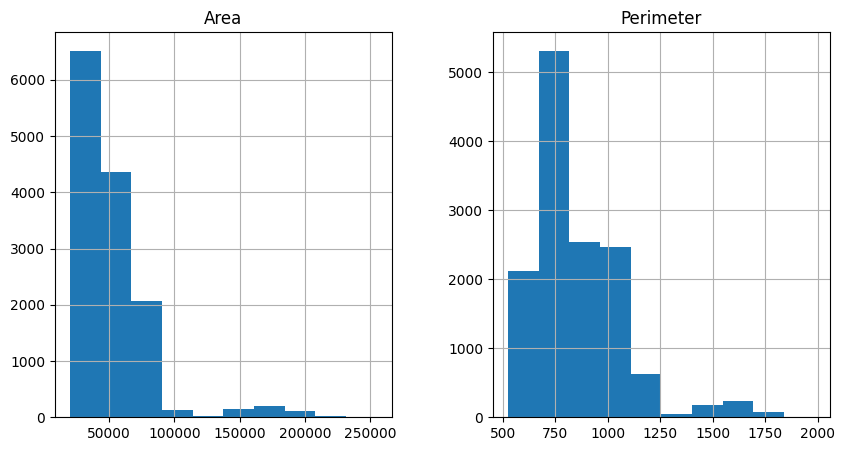

In [ ]:
df[['Area','Perimeter']].hist(figsize=(10,5))
plt.show()

3. Heatmap

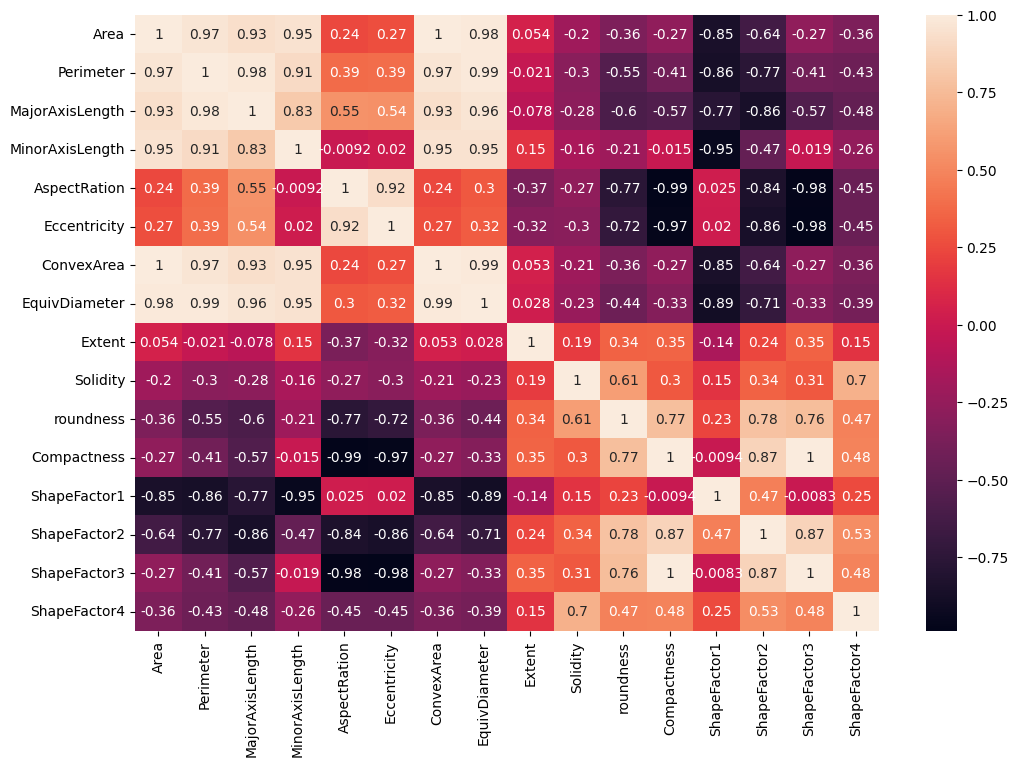

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

**Feature** **Engineering**

In [ ]:
#Label encoding

from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Class']=le.fit_transform(df['Class'])
df

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,5
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,5
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,5
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,5
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13606,42097,759.696,288.721612,185.944705,1.552728,0.765002,42508,231.515799,0.714574,0.990331,0.916603,0.801865,0.006858,0.001749,0.642988,0.998385,3
13607,42101,757.499,281.576392,190.713136,1.476439,0.735702,42494,231.526798,0.799943,0.990752,0.922015,0.822252,0.006688,0.001886,0.676099,0.998219,3
13608,42139,759.321,281.539928,191.187979,1.472582,0.734065,42569,231.631261,0.729932,0.989899,0.918424,0.822730,0.006681,0.001888,0.676884,0.996767,3
13609,42147,763.779,283.382636,190.275731,1.489326,0.741055,42667,231.653248,0.705389,0.987813,0.907906,0.817457,0.006724,0.001852,0.668237,0.995222,3


**Feature** **Selection**

            Feature  Importance
14     ShapeFactor3    0.098171
1         Perimeter    0.097430
12     ShapeFactor1    0.090576
2   MajorAxisLength    0.083420
11      Compactness    0.078836
3   MinorAxisLength    0.075999
6        ConvexArea    0.074595
5      Eccentricity    0.072006
4      AspectRation    0.066057
7     EquivDiameter    0.061980
0              Area    0.052070
10        roundness    0.051992
13     ShapeFactor2    0.035731
15     ShapeFactor4    0.031114
9          Solidity    0.018605
8            Extent    0.011419


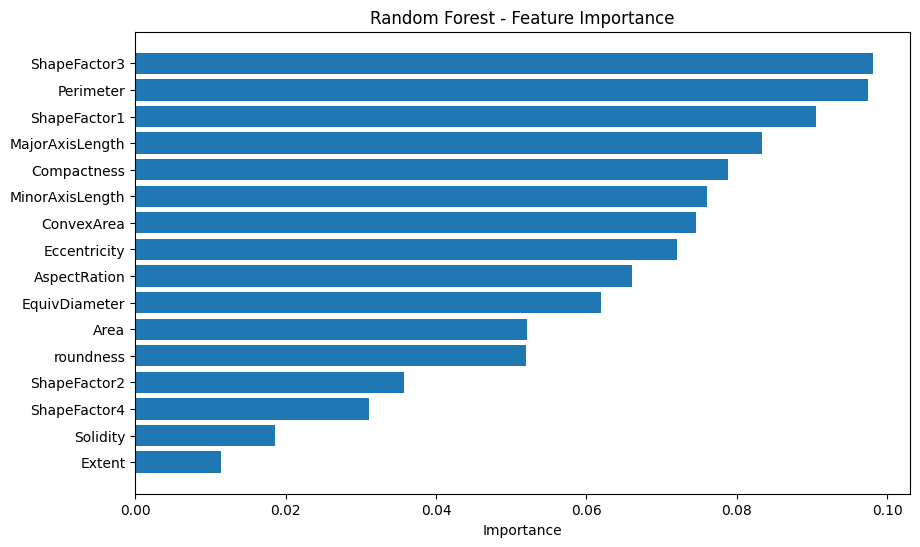

In [ ]:
from sklearn.ensemble import RandomForestClassifier


rf = RandomForestClassifier(n_estimators=100, random_state=42)
y = df['Class']
rf.fit(x_scaled, y)

importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance)

plt.figure(figsize=(10,6))
plt.barh(importance['Feature'], importance['Importance'])
plt.xlabel("Importance")
plt.title("Random Forest - Feature Importance")
plt.gca().invert_yaxis()
plt.show()

**Split** **Data into Training** **and** **testing** **sets**

In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train,X_test,y_train,y_test

(        Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
 11073  29076    636.353       235.061516       158.033619      1.487415   
 13172  38091    755.186       271.077683       179.756984      1.508023   
 11587  30969    651.527       230.164083       171.903953      1.338911   
 12492  34589    685.425       253.001232       174.609358      1.448956   
 430    35954    710.093       251.660769       182.014822      1.382639   
 ...      ...        ...              ...              ...           ...   
 5191   83266   1117.778       448.473710       237.747098      1.886348   
 13418  39857    755.392       283.623668       179.430885      1.580685   
 5390   90004   1156.599       456.836383       252.353553      1.810303   
 860    38426    711.412       246.696608       198.555755      1.242455   
 7270   63628    997.390       400.784151       204.033966      1.964301   
 
        Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
 110

**ML Model**

In [ ]:
models={
        'Logistic Regression': LogisticRegression(max_iter=1000),
    'Support Vector Machine': SVC(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5)
    }
print (models)

{'Logistic Regression': LogisticRegression(max_iter=1000), 'Support Vector Machine': SVC(), 'Decision Tree': DecisionTreeClassifier(), 'Random Forest': RandomForestClassifier(), 'K-Nearest Neighbors': KNeighborsClassifier()}


**Model** **Evaluation**

In [ ]:

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

for model_name, model in models.items():
    print(f"\n--- {model_name} ---")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))


--- Logistic Regression ---
Accuracy: 0.9269188395152406
Confusion Matrix:
 [[238   0  14   0   0   0   9]
 [  0 117   0   0   0   0   0]
 [ 11   0 298   0   4   1   3]
 [  0   0   0 607   1   7  56]
 [  2   0   2   4 392   0   8]
 [  8   0   0   6   0 388  11]
 [  0   0   0  40   7   5 484]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.91      0.92       261
           1       1.00      1.00      1.00       117
           2       0.95      0.94      0.94       317
           3       0.92      0.90      0.91       671
           4       0.97      0.96      0.97       408
           5       0.97      0.94      0.95       413
           6       0.85      0.90      0.87       536

    accuracy                           0.93      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.93      0.93      0.93      2723


--- Support Vector Machine ---
Accuracy: 0.9338964377524789
Confusion Matrix:
 [[24

**Hyperparameter Tuning and Pipeline**

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

pipeline = Pipeline([('scaler', StandardScaler()), ('rf', RandomForestClassifier())])
param_grid = {'rf__n_estimators': [100,200], 'rf__max_depth': [10,20,None]}
grid = GridSearchCV(pipeline, param_grid, cv=3)
grid.fit(X_train, y_train)
print(grid.best_params_)

{'rf__max_depth': None, 'rf__n_estimators': 100}


In [ ]:
import joblib
joblib.dump(grid.best_estimator_,'dry_bean_model.pkl')

['dry_bean_model.pkl']

**Test with Unseen Data**

In [ ]:
new_bean = [[20000, 600, 250, 100, 2.5, 0.8, 20200, 160, 0.7, 0.98, 0.85, 0.75, 0.006, 0.003, 0.85, 0.99]]
new_bean_df=pd.DataFrame(new_bean,columns=x.columns)
print(new_bean_df)
new_bean_scaled=scaler.transform(new_bean_df)
print(new_bean_scaled)
pred_num=grid.predict(new_bean_scaled)
print(pred_num)

    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0  20000        600              250              100           2.5   

   Eccentricity  ConvexArea  EquivDiameter  Extent  Solidity  roundness  \
0           0.8       20200            160     0.7      0.98       0.85   

   Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  
0         0.75         0.006         0.003          0.85          0.99  
[[-1.12704238 -1.19134444 -0.81854379 -2.2742776   3.71654548  0.53376015
  -1.12744008 -1.57269632 -1.01320626 -1.53273065 -0.39117491 -0.80801678
  -0.49967208  2.15498242  2.08510534 -1.15963514]]
[3]


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


**Conclusions**

Random Forest is the best model for Dry Bean dataset because it handles multiclass classification very well and gives 93.5% accuracy. Limitation is some features are highly correlated, so we need to handle multicollinearity. Model can be used in real agriculture sorting machines.